In [9]:
import networkx as nx
import random
import numpy as np
import itertools
import re
from collections import Counter
import seaborn as sns
import pandas as pd
import pickle 
import matplotlib.pyplot as plt

In [2]:
stage_labels = ['L1-0', 'L1-5', 'L1-8', 'L1-16', 'L2', 'L3', 'Ad-45-1', 'Ad-45-2']

In [3]:
stage_labels_plot = ['L1$_{0h}$', 'L1$_{5h}$', 'L1$_{8h}$', 'L1$_{16h}$', 'L2', 'L3', 'Ad$^{1}$', 'Ad$^{2}$']

In [4]:
# It tells Matplotlib's mathtext engine to render math upright (roman) instead of the default italics — 
# without needing to wrap your labels in \mathrm{} or edit the list.
plt.rcParams['mathtext.default'] = 'regular' 

In [7]:
with open('data/processed/all_c_elegans_weighted_graphs.pkl', 'rb') as file:
    all_c_elegans_weighted_graphs = pickle.load(file)

In [5]:
with open("data/processed/C_elegans_normalized_in_degree_rcc_all_networks.pkl", "rb") as f:
    rich_club_data_in_degree = pickle.load(f)

with open("data/processed/C_elegans_normalized_out_degree_rcc_all_networks.pkl", "rb") as f:
    rich_club_data_out_degree = pickle.load(f)

with open("data/processed/C_elegans_normalized_in_degree_weighted_rcc_all_networks.pkl", "rb") as f:
    rich_club_data_Win_degree = pickle.load(f)

with open("data/processed/C_elegans_normalized_out_degree_weighted_rcc_all_networks.pkl", "rb") as f:
    rich_club_data_Wout_degree = pickle.load(f)

In [3]:
with open('data/processed/C_elegans_Dir_UW_RC_Regimes.pkl', 'rb') as file:
    dir_UW_RC_regimes = pickle.load(file)

with open('data/processed/C_elegans_Dir_Wtd_RC_Regimes.pkl', 'rb') as file:
    dir_Wtd_RC_regimes = pickle.load(file)

In [7]:
dir_Wtd_RC_regimes

{'weighted in-degree': [[(2, 27)],
  [(3, 3), (6, 6), (8, 41)],
  [(5, 43)],
  [(6, 50)],
  [(8, 72)],
  [(8, 74)],
  [(13, 108)],
  [(11, 11), (13, 126)]],
 'weighted out-degree': [[(6, 6), (8, 13)],
  [(7, 7), (11, 20)],
  [(6, 6), (12, 22)],
  [(9, 22), (25, 27)],
  [(9, 9), (17, 40), (58, 58)],
  [(5, 6), (28, 44), (68, 72)],
  [(20, 20), (24, 24), (27, 29), (31, 31), (33, 68), (73, 73)],
  [(32, 33), (35, 78), (104, 104)]]}

In [8]:
np.trapz([1.0, 2.0, 3.0], x=[7, 8, 9]), np.trapz([1.0, 3.0], x=[7, 9]), np.trapz([1.0, 5.0, 1.0], x=[7, 8, 9])

(4.0, 4.0, 6.0)

In [9]:
regime_list = dir_UW_RC_regimes['in-degree']
regime_list

[[(1, 13)],
 [(1, 3), (5, 15)],
 [(2, 3), (5, 13)],
 [(2, 15)],
 [(3, 17)],
 [(1, 2), (4, 16)],
 [(1, 2), (8, 10), (14, 21)],
 [(1, 3), (6, 23)]]

In [10]:
dir_UW_RC_regimes['in-degree']

[[(1, 13)],
 [(1, 3), (5, 15)],
 [(2, 3), (5, 13)],
 [(2, 15)],
 [(3, 17)],
 [(1, 2), (4, 16)],
 [(1, 2), (8, 10), (14, 21)],
 [(1, 3), (6, 23)]]

In [22]:
import numpy as np

def compute_auc_from_regimes(regime_list, rc_data_list):
    auc_values = []

    for stage_idx, regimes in enumerate(regime_list):
        stage_data = rc_data_list[stage_idx]
        k_vals = stage_data['k_vals']
        phi_vals = stage_data['phi_norm']

        phi_dict = {k: phi for k, phi in zip(k_vals, phi_vals)}

        stage_auc = 0.0

        for start, end in regimes:
            if start == end:
                # Singleton: rectangular contribution
                stage_auc += (phi_dict[start] - 1)
            else:
                segment_k = [k for k in k_vals if start <= k <= end]
                segment_phi = [phi_dict[k] - 1 for k in segment_k]
                stage_auc += np.trapz(segment_phi, segment_k)  # Trapezoid AUC

        auc_values.append(stage_auc)

    return auc_values


def compute_auc_with_error_from_regimes(regime_list, rc_data_list, n_samples=1000, random_state=None):

    """
    Compute AUC and its uncertainty for rich-club curves using Monte Carlo error propagation.

    For each developmental stage:
      1. The function wiggles the normalized rich-club curve (phi_norm) by sampling
         from a normal distribution defined by its mean (phi_norm) and per-point
         standard deviation (phi_norm_err).
      2. For each wiggled curve, AUC is recomputed over the specified regimes
         (degree intervals where phi_norm > 1) using the same trapezoid method as
         the baseline calculation.
      3. Repeating this many times yields a distribution of AUC values, from which
         the function returns:
             - baseline AUC (no wiggle)
             - mean AUC across samples
             - standard deviation of AUC (AUC error bar)
             - 95% confidence interval (2.5th–97.5th percentiles)
             - all sampled AUC values
    """
    
    if random_state is not None:
        np.random.seed(random_state)

    n_stages = len(rc_data_list)
    # Baseline AUC from the un-wiggled curves
    baseline_auc = compute_auc_from_regimes(regime_list, rc_data_list)

    auc_samples = np.zeros((n_stages, n_samples)) # Rows → different graphs (stages) | Columns → different Monte Carlo samples

    for s in range(n_samples):
        for stage_idx, regimes in enumerate(regime_list):
            stage_data = rc_data_list[stage_idx]
            k_vals = stage_data['k_vals']
            phi_vals = stage_data['phi_norm']
            phi_err = stage_data['phi_norm_err']

            # Wiggle the normalized RCC using its error bar
            phi_sample = np.random.normal(phi_vals, phi_err)

            phi_dict = {k: phi for k, phi in zip(k_vals, phi_sample)}

            stage_auc = 0.0
            for start, end in regimes:
                if start == end:
                    stage_auc += (phi_dict[start] - 1)
                else:
                    segment_k = [k for k in k_vals if start <= k <= end]
                    segment_phi = [phi_dict[k] - 1 for k in segment_k]
                    stage_auc += np.trapz(segment_phi, segment_k)

            auc_samples[stage_idx, s] = stage_auc

    # Summary stats per stage
    auc_mean = auc_samples.mean(axis=1)
    auc_std = auc_samples.std(axis=1, ddof=1)
    auc_ci_low = np.percentile(auc_samples, 2.5, axis=1)
    auc_ci_high = np.percentile(auc_samples, 97.5, axis=1)

    return {
        "auc_baseline": np.array(baseline_auc),
        "auc_mean": auc_mean,
        "auc_std": auc_std,
        "auc_ci_low": auc_ci_low,
        "auc_ci_high": auc_ci_high,
        "auc_samples": auc_samples,
    }


In [24]:
compute_auc_with_error_from_regimes(
    dir_UW_RC_regimes['in-degree'],
    rich_club_data_in_degree
)

{'auc_baseline': array([3.21217258, 4.10593524, 1.58877877, 3.17418757, 3.44260986,
        2.21140808, 2.20913716, 3.59964255]),
 'auc_mean': array([3.22483446, 4.14897963, 1.60809355, 3.18458286, 3.43777415,
        2.21298564, 2.19664638, 3.56790395]),
 'auc_std': array([0.61790853, 0.5926603 , 0.29385518, 0.44263099, 0.33462911,
        0.24730596, 0.31276514, 0.53347744]),
 'auc_ci_low': array([1.97626954, 2.95209594, 1.03886602, 2.29884485, 2.79265571,
        1.70315372, 1.56998508, 2.48980197]),
 'auc_ci_high': array([4.42180188, 5.28792849, 2.17632897, 4.02555266, 4.09954825,
        2.67675171, 2.80884593, 4.61902637]),
 'auc_samples': array([[3.0090034 , 2.83575025, 2.9498379 , ..., 3.22616464, 2.9955105 ,
         2.75933286],
        [3.64772827, 4.33751875, 3.94881982, ..., 4.23206991, 3.88196242,
         5.00720459],
        [1.92561109, 1.7725798 , 1.99256885, ..., 1.7340173 , 1.58229297,
         1.65964618],
        ...,
        [2.54709607, 2.1678575 , 1.97144271, .

In [26]:
# Unweighted in-degree
res_in_UW = compute_auc_with_error_from_regimes(
    dir_UW_RC_regimes['in-degree'],
    rich_club_data_in_degree,
    n_samples=1000,
    random_state=0
)

# Unweighted out-degree
res_out_UW = compute_auc_with_error_from_regimes(
    dir_UW_RC_regimes['out-degree'],
    rich_club_data_out_degree,
    n_samples=1000,
    random_state=1
)

# Weighted in-degree
res_in_W = compute_auc_with_error_from_regimes(
    dir_Wtd_RC_regimes['weighted in-degree'],
    rich_club_data_Win_degree,
    n_samples=1000,
    random_state=2
)

# Weighted out-degree
res_out_W = compute_auc_with_error_from_regimes(
    dir_Wtd_RC_regimes['weighted out-degree'],
    rich_club_data_Wout_degree,
    n_samples=1000,
    random_state=3
)


In [29]:
#with open('data/processed/C_elegans_rich_clubs_AUC_statistics.pkl', 'wb') as file:
    #pickle.dump([res_in_UW, res_out_UW, res_in_W, res_out_W], file)

In [11]:
with open('data/processed/C_elegans_rich_clubs_AUC_statistics.pkl', 'rb') as file:
    res_in_UW, res_out_UW, res_in_W, res_out_W = pickle.load(file)

In [13]:
res_in_W

{'auc_baseline': array([ 8.27323602, 14.65525119, 13.58106394, 17.52136149, 17.23516371,
        21.09051306, 24.70558935, 33.90373082]),
 'auc_mean': array([ 8.22040662, 14.4921961 , 13.61256301, 17.44499324, 17.26004261,
        21.00990806, 24.65126128, 33.88013101]),
 'auc_std': array([1.12290741, 2.24948776, 1.70952552, 1.34441246, 1.48208732,
        1.56818571, 1.99190173, 2.58341564]),
 'auc_ci_low': array([ 6.00748436, 10.10175782, 10.35362978, 14.89042231, 14.29817283,
        18.1718309 , 20.50117934, 28.64451856]),
 'auc_ci_high': array([10.27450794, 18.99674802, 16.87885324, 20.16882287, 20.14661264,
        24.12743634, 28.67751202, 38.91532021]),
 'auc_samples': array([[ 7.2140801 ,  8.28262671,  7.41327983, ...,  7.74964441,
          8.19349946,  9.14694991],
        [14.25425878,  9.16000806, 13.34471184, ..., 11.74040651,
         15.8222754 , 13.24568019],
        [14.93150446, 12.14028788, 11.94468644, ..., 12.96327585,
         12.81997824, 13.367789  ],
        .

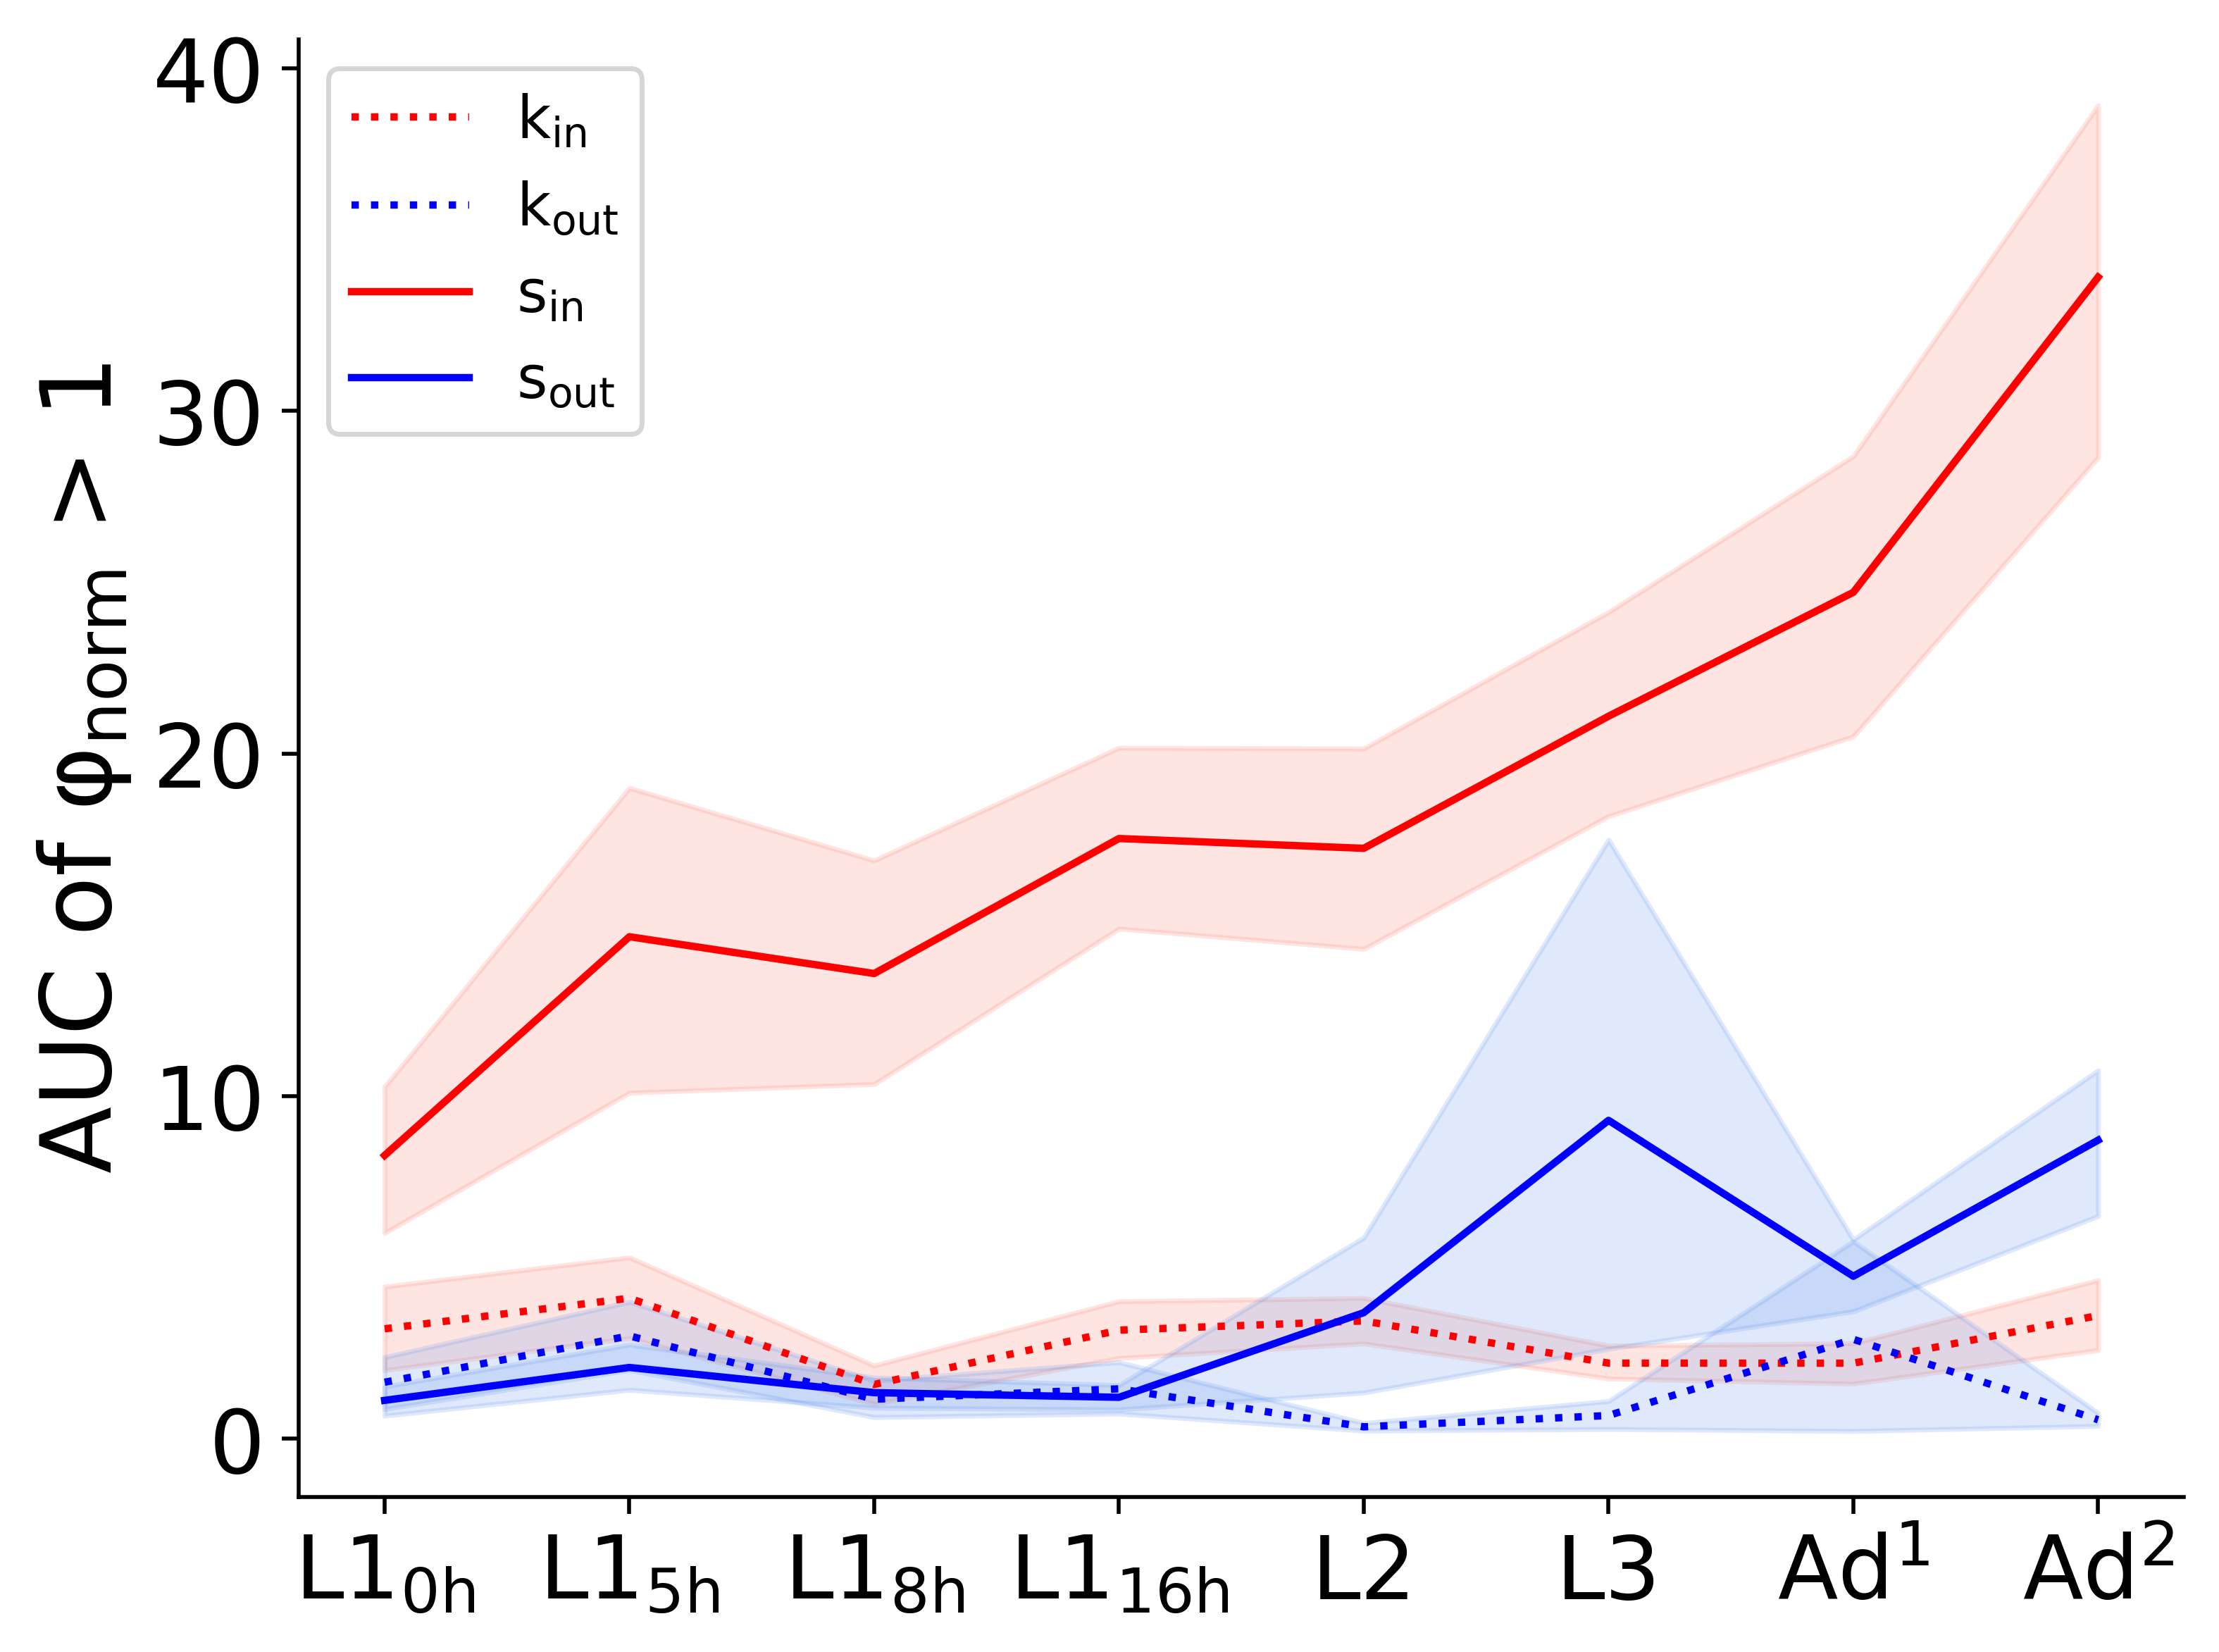

In [91]:
import numpy as np
import matplotlib.pyplot as plt

n_stages = len(rich_club_data_in_degree)  # or any of the rc_data_list
stages = np.arange(1, n_stages + 1)       # x-axis = stage index (1..8)

plt.figure(dpi=500)

# --- Unweighted in-degree ---
plt.plot(stage_labels_plot, res_in_UW['auc_baseline'], linestyle=':',color='red', label='$k_{in}$')
plt.fill_between(
    stage_labels_plot,
    res_in_UW['auc_ci_low'],
    res_in_UW['auc_ci_high'],
    color='salmon',
    alpha=0.2
)

# --- Unweighted out-degree ---
plt.plot(stage_labels_plot, res_out_UW['auc_baseline'], linestyle=':', color='blue', label='$k_{out}$')
plt.fill_between(
    stage_labels_plot,
    res_out_UW['auc_ci_low'],
    res_out_UW['auc_ci_high'],
    color='cornflowerblue',
    alpha=0.2
)

# --- Weighted in-degree ---
plt.plot(stage_labels_plot, res_in_W['auc_baseline'], linestyle='-', color='red', label='$s_{in}$')
plt.fill_between(
    stage_labels_plot,
    res_in_W['auc_ci_low'],
    res_in_W['auc_ci_high'],
    color='salmon',
    alpha=0.2
)

# --- Weighted out-degree ---
plt.plot(stage_labels_plot, res_out_W['auc_baseline'], linestyle='-', color='blue', label='$s_{out}$')
plt.fill_between(
    stage_labels_plot,
    res_out_W['auc_ci_low'],
    res_out_W['auc_ci_high'],
    color='cornflowerblue',
    alpha=0.2
)
ax = plt.gca()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.ylabel('AUC of $φ_{norm}$ > 1', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=18)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()
